# 02 — αβ Back-EMF Observer (Structure B) Running in Parallel

**Stage 2** of the sensorless-drive build. Same plant + controller as notebook 01 (the
controller still uses the plant's **real** θr/ωmech — nothing about the control loop changes),
with the **αβ Structure-B (PI-corrected Luenberger) back-EMF observer + PLL** added running
*passively* alongside it: fed by the real, measurable α/β currents and the real, measurable
α/β applied voltage (both expressed via the real θr, since the controller isn't using an
estimate yet — no angle mismatch exists in this notebook). Its θ̂/ω̂ outputs are only monitored
and plotted here, to validate the observer's own tuning **before** trusting it to close the
loop in notebook 03.

See `PLAN.md` and `PMSM_Sensorless_Model_Spec.pdf` (pages 4-5, 7) for the observer/PLL
equations, gain derivation, and block diagram.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pmsm_common as pc

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Parameters (plant/controller as in notebook 01, plus observer + PLL gains)

In [2]:
p = pc.make_params()

print(f"Current loop:  Kp_d={p.Kp_d:.3f} Ki_d={p.Ki_d:.1f}  Kp_q={p.Kp_q:.3f} Ki_q={p.Ki_q:.1f}")
print(f"Observer (Structure B, L_obs={p.L_obs*1e6:.1f} uH, omega_n={pc.omega_n_obs:.0f} rad/s):")
print(f"  Ki_P={p.Ki_P:.1f}  Ki_I={p.Ki_I:.3e}  Ke_P={p.Ke_P:.1f}  Ke_I={p.Ke_I:.3e}")
print(f"PLL (omega_n={pc.omega_n_pll:.0f} rad/s, zeta={pc.zeta_pll}):")
print(f"  Kp_pll={p.Kp_pll:.1f}  Ki_pll={p.Ki_pll:.3e}")

Current loop:  Kp_d=9.000 Ki_d=900.0  Kp_q=8.800 Ki_q=900.0
Observer (Structure B, L_obs=178.0 uH, omega_n=80000 rad/s):
  Ki_P=239898.9  Ki_I=1.280e+10  Ke_P=1139200.0  Ke_I=9.114e+10
PLL (omega_n=15000 rad/s, zeta=0.707):
  Kp_pll=21210.0  Ki_pll=2.250e+08


## 2. Plant + controller + observer + PLL right-hand side

State layout (see `pmsm_common.py`):
`x = [isd, isq, omega_mech, theta_r, xi_d, xi_q,` &nbsp;
`ia_hat, ib_hat, ea_hat, eb_hat, z_a, z_b, theta_pll, omega_pll]` (14 states).

States 0-5 (plant+controller) are **identical** to notebook 01 — the controller still uses
the plant's real θr/ωmech. States 6-13 are the observer + PLL, running open-loop /
"read-only": they consume the real α/β currents and the real α/β applied voltage (obtained
by rotating the plant's own dq quantities by the real θr — there's no angle mismatch to model
yet, that's notebook 03) and never feed back into the controller.

In [3]:
def rhs_nb2(t, x, p):
    (isd, isq, omega_mech, theta_r, xi_d, xi_q,
     ia_hat, ib_hat, ea_hat, eb_hat, z_a, z_b, theta_pll, omega_pll) = x
    omega_r = p.p * omega_mech

    # ===================== plant + controller (identical to notebook 01) =====================
    err_d = p.isd_ref - isd
    err_q = p.isq_ref - isq
    ff_d = -omega_r * p.Lq * isq
    ff_q = omega_r * p.Ld * isd + omega_r * p.psi_m_pi
    usd_unsat = p.Kp_d * err_d + xi_d + ff_d
    usq_unsat = p.Kp_q * err_q + xi_q + ff_q
    usd, usq, _sat = pc.saturate_voltage(usd_unsat, usq_unsat, p.Vmax)
    dxi_d = p.Ki_d * err_d + pc.antiwindup_term(usd_unsat, usd, p.Kp_d)
    dxi_q = p.Ki_q * err_q + pc.antiwindup_term(usq_unsat, usq, p.Kp_q)

    disd = (usd - p.Rs * isd + omega_r * p.Lq * isq) / p.Ld
    disq = (usq - p.Rs * isq - omega_r * p.Ld * isd - omega_r * p.psi_m_pi) / p.Lq

    Te = p.p * p.psi_m_pi * isq + p.p * (p.Ld - p.Lq) * isd * isq
    T_load = p.k_fan * omega_mech * abs(omega_mech)
    domega_mech = (Te - T_load - p.B * omega_mech) / p.J
    dtheta_r = omega_r

    # ===================== alpha-beta observer input (real, measurable) =====================
    # No angle mismatch in this notebook: controller uses theta_r, so the "measured" alpha-beta
    # currents/voltage are obtained via the same real theta_r used by the controller.
    i_alpha, i_beta = pc.dq_to_alphabeta(isd, isq, theta_r)
    v_alpha, v_beta = pc.dq_to_alphabeta(usd, usq, theta_r)

    # ===================== Structure-B observer =====================
    di_a = i_alpha - ia_hat
    di_b = i_beta - ib_hat
    dia_hat = (-(p.Rs / p.L_obs) * ia_hat - (1 / p.L_obs) * ea_hat + (1 / p.L_obs) * v_alpha
               + p.Ki_P * di_a + p.Ki_I * z_a)
    dib_hat = (-(p.Rs / p.L_obs) * ib_hat - (1 / p.L_obs) * eb_hat + (1 / p.L_obs) * v_beta
               + p.Ki_P * di_b + p.Ki_I * z_b)
    dea_hat = -(p.Ke_P * di_a + p.Ke_I * z_a)
    deb_hat = -(p.Ke_P * di_b + p.Ke_I * z_b)
    dz_a = di_a
    dz_b = di_b

    # ===================== PLL (position/speed extraction) =====================
    theta_raw = np.arctan2(-ea_hat, eb_hat)
    phase_err = np.sin(theta_raw - theta_pll)          # wrap-safe phase detector
    dtheta_pll = omega_pll + p.Kp_pll * phase_err
    domega_pll = p.Ki_pll * phase_err

    return [disd, disq, domega_mech, dtheta_r, dxi_d, dxi_q,
            dia_hat, dib_hat, dea_hat, deb_hat, dz_a, dz_b, dtheta_pll, domega_pll]

## 3. Torque-command schedule simulation (same schedule as notebook 01)

In [4]:
torque_levels = [0, 10, 30, 50, 70, 10, 70, -20, 50]

x0 = np.zeros(14)
p = pc.make_params()

import time
t0 = time.time()
result = pc.simulate_schedule(rhs_nb2, x0, p, torque_levels)
print(f"simulated {result.t[-1]:.3f} s of drive time in {time.time()-t0:.1f} s wall-clock, "
      f"{result.t.size} samples")
print("converged per level:", result.converged_flags)

simulated 5.845 s of drive time in 96.5 s wall-clock, 1370103 samples
converged per level: [True, True, True, True, True, True, True, True, True]


## 4. Results — plant (as notebook 01)

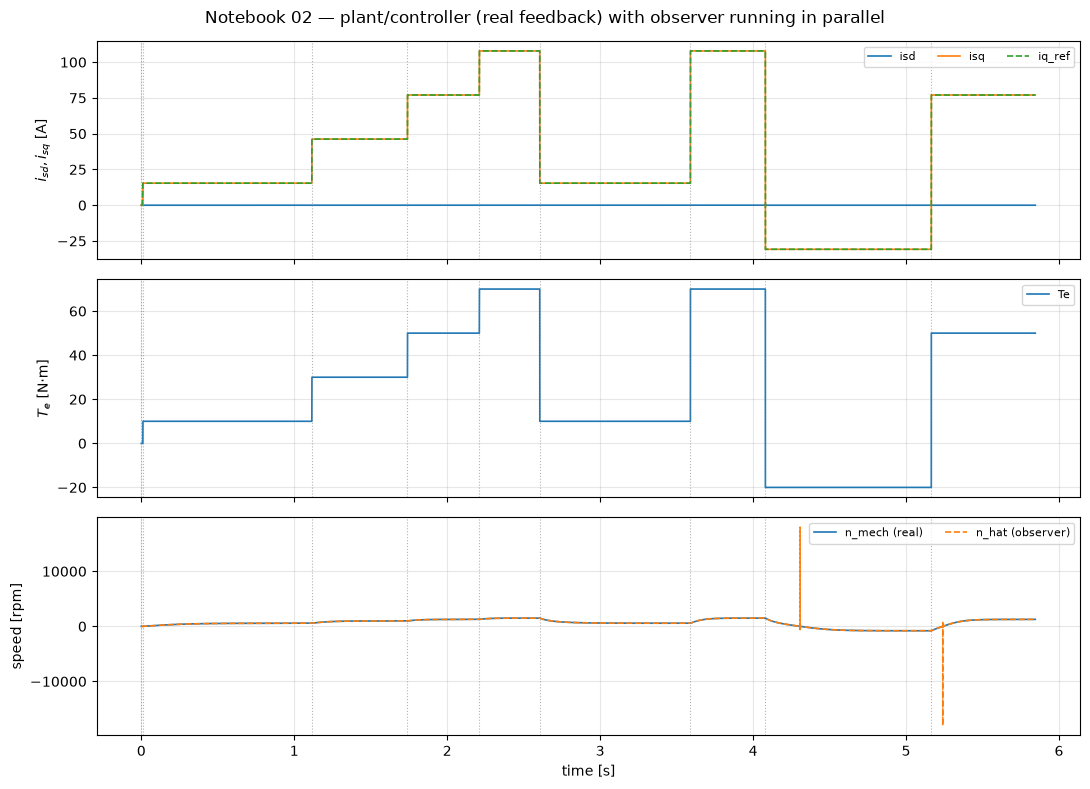

In [5]:
t = result.t
X = result.X
isd, isq, omega_mech, theta_r = X[0], X[1], X[2], X[3]
theta_pll, omega_pll = X[12], X[13]
ea_hat, eb_hat = X[8], X[9]

level_times = result.level_times
level_values = result.level_values
iq_ref_t = np.piecewise(t, [t >= lt for lt in level_times],
                         [v / (p.p * p.psi_m_pi) for v in level_values])
Te = p.p * p.psi_m_pi * isq + p.p * (p.Ld - p.Lq) * isd * isq
n_mech = omega_mech * 60 / (2 * np.pi)
n_hat = (omega_pll / p.p) * 60 / (2 * np.pi)

fig, axes = pc.plot_traces(
    t,
    {
        r"$i_{sd},i_{sq}$ [A]": [("isd", isd), ("isq", isq), ("iq_ref", iq_ref_t, "--")],
        r"$T_e$ [N·m]": [("Te", Te)],
        "speed [rpm]": [("n_mech (real)", n_mech), ("n_hat (observer)", n_hat, "--")],
    },
    level_times=level_times,
    title="Notebook 02 — plant/controller (real feedback) with observer running in parallel",
)

## 5. Observer validation — θ̂ vs θr, ω̂ vs ωmech

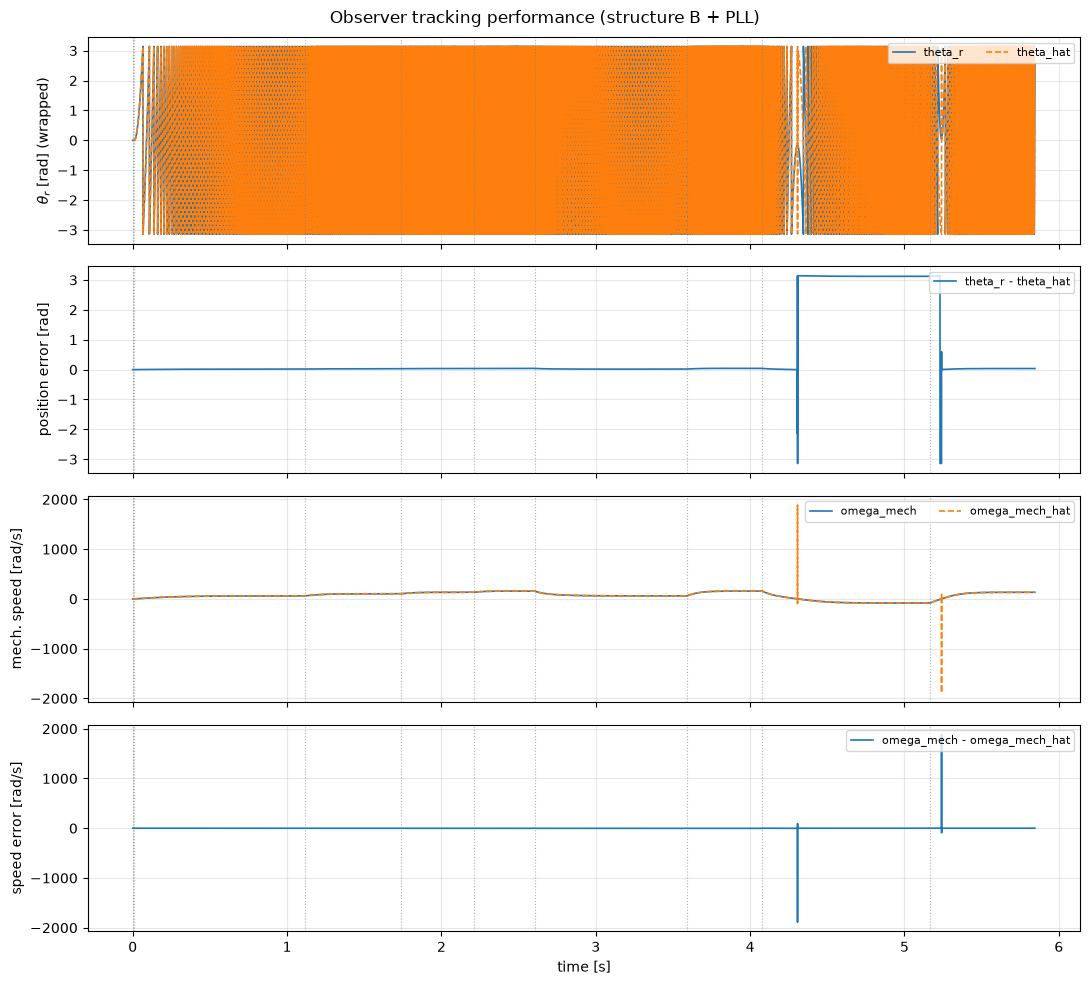

In [6]:
theta_r_wrapped = pc.wrap_to_pi(theta_r)
theta_hat_wrapped = pc.wrap_to_pi(theta_pll)
theta_err = pc.wrap_to_pi(theta_r - theta_pll)          # signed shortest-path angle error
omega_mech_hat = omega_pll / p.p
omega_err = omega_mech - omega_mech_hat

fig, axes = pc.plot_traces(
    t,
    {
        r"$\theta_r$ [rad] (wrapped)": [("theta_r", theta_r_wrapped), ("theta_hat", theta_hat_wrapped, "--")],
        "position error [rad]": [("theta_r - theta_hat", theta_err)],
        "mech. speed [rad/s]": [("omega_mech", omega_mech), ("omega_mech_hat", omega_mech_hat, "--")],
        "speed error [rad/s]": [("omega_mech - omega_mech_hat", omega_err)],
    },
    level_times=level_times,
    title="Observer tracking performance (structure B + PLL)",
    figsize=(11, 10),
)

## 6. Discussion

- At medium/high speed (the 30/50/70 N·m levels, several hundred to ~1500 rpm) the observer
  locks onto θr/ωmech with a small, **speed-proportional steady-state position bias** (a few
  hundredths of a rad at rated speed) and near-zero speed error. This bias is not a bug: the
  observer's αβ model assumes an isotropic machine (`L_obs=(Ld+Lq)/2`), but the real machine
  is slightly salient (`Ld≠Lq`, ~2%); that structural mismatch acts as a disturbance rotating
  at the electrical frequency, which pure P+I correction can reduce (by raising `omega_n_obs`)
  but never fully cancel — a classic sinusoidal-disturbance-rejection limit, not a DC bias a
  plain integrator would drive to zero. `pmsm_common.py` documents the empirical bandwidth
  sweep behind the chosen gains.
- Expect a **large, sustained ~π error during the entire `-20` N·m (negative-speed) level** —
  and this turns out to be exact and deterministic, not a transient loss of lock. The
  position-recovery formula comes from `e_α,e_β ∝ ω·(cosθr, sinθr)`: whenever `ω<0`, that's a
  *negative* scalar times `(cosθr,sinθr)`, which is indistinguishable from a *positive*
  magnitude at angle `θr+π` — so `atan2(-êα,êβ)` recovers `θr+π` for as long as speed stays
  negative, with no way to tell from the back-EMF vector alone. This is a well-known,
  fundamental limitation of pure back-EMF-angle sensorless estimation (real drives resolve it
  with an independent sign-of-speed reference, e.g. from the commanded iq or prior PLL
  history) — out of scope here, so we surface it rather than engineer around it. Watch for its
  consequences once the controller actually trusts this estimate, in notebook 03.
- Near true standstill (start of the run) the back-EMF magnitude itself is ~0, so the angle
  is briefly undefined/noisy regardless of sign — the other classic weak point from
  `Literature/mmscience_2015-03_...pdf` §5.
- Notice the large `omega_pll` **transient spike** right at the ~π jumps (both into and out of
  the `-20` N·m level, plot below): the PLL's raw input `theta_raw` jumps almost
  discontinuously by ~π, and a PLL fast enough to keep the steady-state bias small (needed
  above) is also fast enough to slew aggressively — briefly overshooting to an unphysical
  speed estimate — while re-acquiring lock. A genuine bandwidth/robustness trade-off, not a
  bug; worth remembering once notebook 03's controller actually reacts to `omega_hat`.
- Print the peak/steady-state error per level below as a quick numeric summary.

In [7]:
print(f"{'Tref':>6} {'peak |theta_err|':>18} {'end |theta_err|':>16} {'end |omega_err|':>16}")
for i, (lt, lv) in enumerate(zip(level_times, level_values)):
    next_lt = level_times[i + 1] if i + 1 < len(level_times) else t[-1]
    mask = (t >= lt) & (t <= next_lt)
    end_idx = np.where(mask)[0][-1]
    print(f"{lv:6.0f} {np.max(np.abs(theta_err[mask])):18.3f} "
          f"{abs(theta_err[end_idx]):16.4f} {abs(omega_err[end_idx]):16.4f}")

  Tref   peak |theta_err|  end |theta_err|  end |omega_err|
     0              0.000           0.0000           0.0000
    10              0.015           0.0153           0.0001
    30              0.027           0.0271           0.0001
    50              0.036           0.0355           0.0001
    70              0.043           0.0426           0.0000
    10              0.043           0.0153           0.0001
    70              0.043           0.0426           0.0000
   -20              3.142           3.1197           0.0001
    50              3.142           0.0355           0.0001


## Next

`03_pmsm_sensorless_control.ipynb` switches the controller's feedback from the plant's real
θr/ωmech to this observer's θ̂/ω̂ — the fully sensorless configuration — and models the
resulting angle-mismatch physics explicitly (see spec PDF page 8).